# 1. Thiết lập và load dữ liệu

Khởi tạo môi trường và load dữ liệu World Governance Indicators (WGI).

Thực hiện:

* Cấu hình đường dẫn và import module từ `src/`
* Load file dữ liệu CSV
* Lấy giá trị của năm gần nhất

In [1]:
# ===============================
# Setup (Clean & Minimal)
# ===============================
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from scipy.cluster.hierarchy import dendrogram

# ===== Path =====
ROOT = Path.cwd().resolve().parent
SRC_DIR = ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import utils as src_utils
import model as src_model

# Reload tránh cache
src_utils = importlib.reload(src_utils)
src_model = importlib.reload(src_model)

# ===== Alias (only needed) =====
build_triplets = src_utils.build_cosine_triplets
run_adds3_al = src_model.adds3_al



# 2. Tiền xử lý dữ liệu

Xử lý dữ liệu trước khi đưa vào mô hình:

* Lọc các chỉ số quan trọng (GDP, FDI, Governance, Education, etc.)
* Pivot dữ liệu về dạng (country × features)
* Xử lý missing value bằng KNN Imputation
* Chuẩn hóa dữ liệu bằng StandardScaler

In [2]:
SELECTED_INDICATORS = {
    "NY.GDP.PCAP.CD": "GDP per capita",
    "BX.KLT.DINV.WD.GD.ZS": "FDI (% GDP)",
    "GE.EST": "Gov Effectiveness",
    "CC.EST": "Corruption Control",
    "SP.DYN.LE00.IN": "Life Expectancy",
    "SE.TER.ENRR": "Tertiary Enrollment",
    "TX.VAL.TECH.MF.ZS": "High-tech Export"
}

csv_path = ROOT / "data" / "wgi.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"File not found: {csv_path}")

df = pd.read_csv(csv_path)

# ===== Get latest year =====
year_cols = [c for c in df.columns if "[YR" in c]
latest_year = year_cols[-1]
df[latest_year] = pd.to_numeric(df[latest_year], errors="coerce")

# ===== Filter indicators =====
df = df[df["Series Code"].isin(SELECTED_INDICATORS.keys())]

# ===== Pivot =====
df_wide = df.pivot_table(
    index="Country Name",
    columns="Series Code",
    values=latest_year,
    aggfunc="mean"
)

df_wide.rename(columns=SELECTED_INDICATORS, inplace=True)

print(f"Loaded data from: {csv_path}")
print(f"Shape: {df_wide.shape}")

Loaded data from: D:\HCMUS\HK7\DM\lab3\DM-LAB3\data\wgi.csv
Shape: (14, 7)


# 3. Sinh triplets từ dữ liệu

Xây dựng các ràng buộc so sánh (triplets) từ đặc trưng quốc gia.

Cách thực hiện:

* Sử dụng cosine similarity để sinh triplets
* Điều chỉnh số lượng thông qua k_factor

In [3]:
# KNN Imputation
imputer = KNNImputer(n_neighbors=3, weights="distance")
X_imputed = imputer.fit_transform(df_wide)

# Standardization
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed)

countries = df_wide.index.to_numpy()

print(f"Processed: {X.shape[0]} countries, {X.shape[1]} features")

Processed: 14 countries, 7 features


# 4. Phân cụm bằng AddS3-AL

Áp dụng phương pháp AddS3-AL để:

* Xây dựng similarity từ triplets
* Thực hiện hierarchical clustering

Đầu ra:

* Ma trận linkage (Z)
* Cấu trúc phân cụm phân cấp


In [4]:
# ===============================
# Triplets + AddS3
# ===============================

triplets = build_triplets(
    X,
    k_factor=4.0,
    random_state=42
)

print(f"Generated {len(triplets)} triplets")

Z, S = run_adds3_al(len(X), triplets)

print("AddS3-AL completed")

Generated 784 triplets
AddS3-AL completed


# 5. Trực quan hóa kết quả phân cụm

Vẽ dendrogram để biểu diễn cấu trúc phân cụm:

* Trục x: các quốc gia
* Trục y: độ khác biệt (triplet-based divergence)
* Quan sát các nhóm quốc gia tương đồng


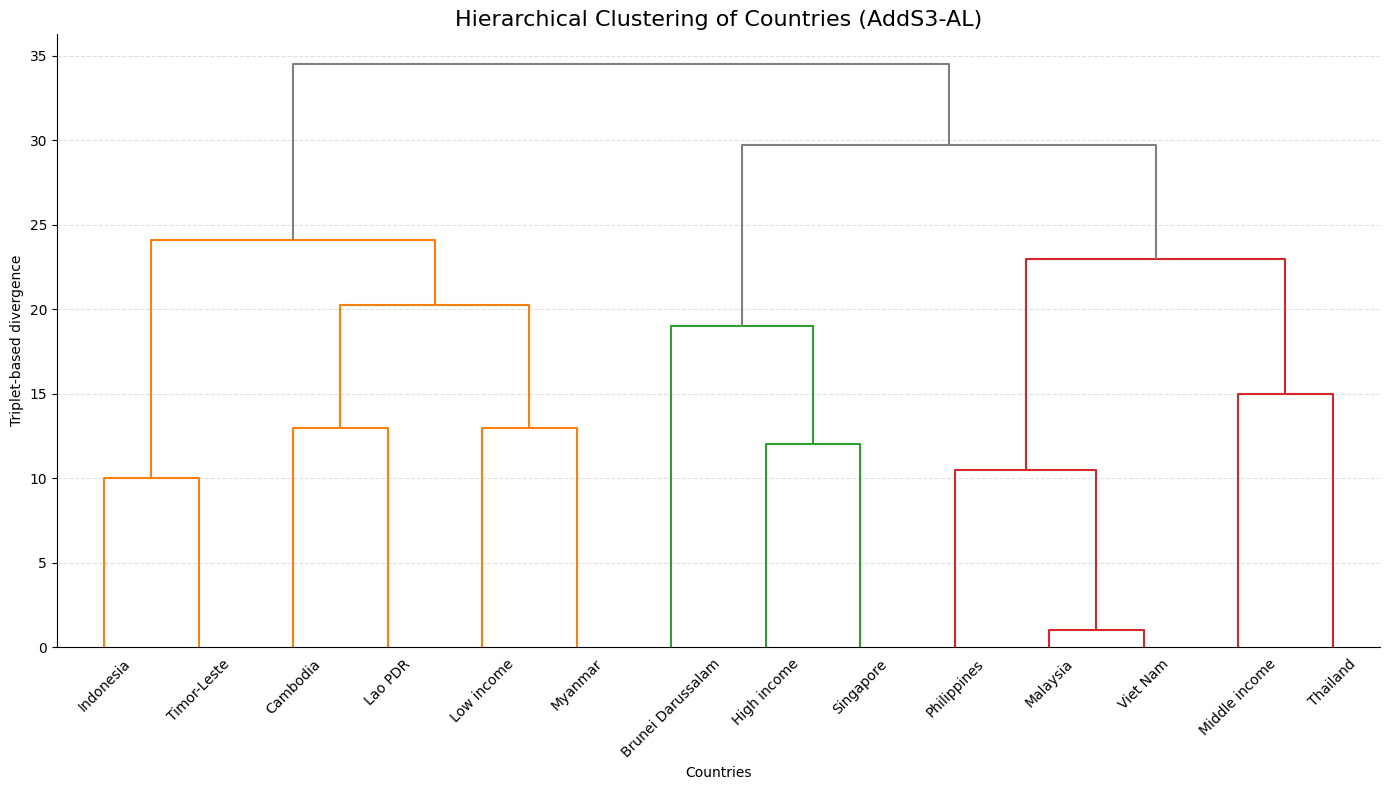

In [5]:

plt.figure(figsize=(14, 8))

dendrogram(
    Z,
    labels=countries,
    leaf_rotation=45,
    leaf_font_size=10,
    above_threshold_color="gray"
)

plt.title("Hierarchical Clustering of Countries (AddS3-AL)", fontsize=16)
plt.ylabel("Triplet-based divergence")
plt.xlabel("Countries")

plt.grid(axis="y", linestyle="--", alpha=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()